# Traffic Collision Data Analysis

# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.



As an analyst examining traffic safety trends, the task would be to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS).
Here's the link https://www.kaggle.com/datasets/alexgude/california-traffic-collision-data-from-switrs.
 It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Tasks Involved

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Load the processed dataset as CSV files in S3/MinIO bucket.</br>
    4.2. Identify the top 5 counties with the highest number of collisions.</br>
    4.3. Identify the month with the highest number of collisions.</br>
    4.4. Determine the most common weather condition during collisions.</br>
    4.5. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.6. Find the most dangerous time of day for collisions.</br>
    4.7. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.8. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
  
    
</br>
</ol>

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Install Required Libraries

In [1]:
## Install the required libraries
!pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [1]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

#**1. Data Preparation** <font color = red></font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [ ]:
from pyspark.sql import SparkSession
#Connecting to minio bucket
spark = SparkSession.builder \
    .appName("MinIO Safe Setup") \
    .config(
        "spark.jars",
        "/home/jovyan/spark-jars/hadoop-aws-3.3.4.jar,/home/jovyan/spark-jars/aws-java-sdk-bundle-1.12.262.jar"
    ) \
    .config("spark.hadoop.fs.s3a.endpoint", "http://host.docker.internal:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "insert_name_here") \
    .config("spark.hadoop.fs.s3a.secret.key", "insert_password") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("Ready")

Ready


In [3]:
# Write code to load the data and check the schema

# Loading the files
case_ids = spark.read.csv(
    "s3a://mybucket/sample_case_ids.csv",
    header=True,
    inferSchema=True
)

collisions = spark.read.csv(
    "s3a://mybucket/sample_collisions.csv",
    header=True,
    inferSchema=True
)

parties = spark.read.csv(
    "s3a://mybucket/sample_parties.csv",
    header=True,
    inferSchema=True
)

victims = spark.read.csv(
    "s3a://mybucket/sample_victims.csv",
    header=True,
    inferSchema=True
)

print("All files loaded")

All files loaded


In [4]:
#Checking the schema
case_ids.printSchema()
collisions.printSchema()
parties.printSchema()
victims.printSchema()

root
 |-- case_id: double (nullable = true)
 |-- db_year: integer (nullable = true)

root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_cou

#**2. Data Cleaning** <font color = red></font> <br>


In [5]:
#Display Schema & Sample Data


# Victims
print("=== VICTIMS SCHEMA ===")
victims.printSchema()
print("=== VICTIMS SAMPLE DATA ===")
victims.show(5, truncate=False)

# Parties
print("=== PARTIES SCHEMA ===")
parties.printSchema()
print("=== PARTIES SAMPLE DATA ===")
parties.show(5, truncate=False)

# Collisions
print("=== COLLISIONS SCHEMA ===")
collisions.printSchema()
print("=== COLLISIONS SAMPLE DATA ===")
collisions.show(5, truncate=False)

# Case IDs
print("=== CASE_IDS SCHEMA ===")
case_ids.printSchema()
print("=== CASE_IDS SAMPLE DATA ===")
case_ids.show(5, truncate=False)

=== VICTIMS SCHEMA ===
root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)

=== VICTIMS SAMPLE DATA ===
+-------+-----------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------------+--------------+
|id     |case_id    |party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2      |victim_ejected|
+-------+-----------+------------+-----------+-

##**2.1 Missing Values** <font color = red></font> <br>


In [6]:
#Check for Missing Values
from pyspark.sql.functions import col, sum, when

# Function to check missing/null values
def check_missing(df, name):
    print(f"=== Missing Values in {name} ===")
    
    df.select([
        sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).show(truncate=False)

# Check all DataFrames
check_missing(victims, "VICTIMS")
check_missing(parties, "PARTIES")
check_missing(collisions, "COLLISIONS")
check_missing(case_ids, "CASE_IDS")

=== Missing Values in VICTIMS ===
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|id |case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|0  |0      |0           |1          |24041     |32145     |0                      |1913                   |55215                    |310220                   |4272          |
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+

=== Missing Values in PARTIES ===
+---+-------+------------+----------+--------+-----

In [7]:
from pyspark.sql.functions import round

# Function to check missing values as percentage of total rows
def missing_percentage(df, name):
    total_rows = df.count()
    
    print(f"=== Missing Value % in {name} (Total Rows = {total_rows}) ===")
    
    df.select([
        round(
            (sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)) / total_rows) * 100,
            2
        ).alias(c)
        for c in df.columns
    ]).show(truncate=False)

# Run for all DataFrames
missing_percentage(victims, "VICTIMS")
missing_percentage(parties, "PARTIES")
missing_percentage(collisions, "COLLISIONS")
missing_percentage(case_ids, "CASE_IDS")

=== Missing Value % in VICTIMS (Total Rows = 963933) ===
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|id |case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|0.0|0.0    |0.0         |0.0        |2.49      |3.33      |0.0                    |0.2                    |5.73                     |32.18                    |0.44          |
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+

=== Missing Value % in PARTIES (Total Rows = 1866917) ===
+---

In [4]:
#saving lat long data before dropping for further analysis
from pyspark.sql import functions as F

# 1. Isolate the 30% "Useful" Data
# We select the columns needed for spatial/temporal analysis
lat_long_data = collisions.filter(
    F.col("latitude").isNotNull() & 
    F.col("longitude").isNotNull() &
    (F.col("latitude") != 0)
)

# 2. Save to minio bucket in Parquet format

output_path = "s3a://mybucket/"

lat_long_data.write.mode("overwrite").parquet(f"{output_path}lat_long_data.parquet")

print(f"Successfully saved clean subset to {output_path}")

Successfully saved clean subset to s3a://mybucket/


In [4]:
#Drop Sparse Columns
# Drop sparse columns based on missing-value threshold
# Example: drop columns with > 50% missing values

from pyspark.sql.functions import col, sum, when

THRESHOLD = 50.0   # change if needed

def drop_sparse_columns(df, name, threshold=50.0):
    total_rows = df.count()

    # Calculate missing percentages
    missing_stats = df.select([
        (
            (sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)) / total_rows) * 100
        ).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()

    # Columns to drop
    drop_cols = [c for c, pct in missing_stats.items() if pct > threshold]

    # Keep remaining columns
    cleaned_df = df.drop(*drop_cols)

    print(f"\n=== {name} ===")
    print(f"Columns Dropped (> {threshold}% missing): {drop_cols}")
    print(f"Remaining Columns: {len(cleaned_df.columns)}")

    return cleaned_df

# Apply to all DataFrames
victims_clean = drop_sparse_columns(victims, "VICTIMS", THRESHOLD)
parties_clean = drop_sparse_columns(parties, "PARTIES", THRESHOLD)
collisions_clean = drop_sparse_columns(collisions, "COLLISIONS", THRESHOLD)
case_ids_clean = drop_sparse_columns(case_ids, "CASE_IDS", THRESHOLD)

# Check new schemas
victims_clean.printSchema()
parties_clean.printSchema()
collisions_clean.printSchema()
case_ids_clean.printSchema()


=== VICTIMS ===
Columns Dropped (> 50.0% missing): []
Remaining Columns: 11

=== PARTIES ===
Columns Dropped (> 50.0% missing): []
Remaining Columns: 24

=== COLLISIONS ===
Columns Dropped (> 50.0% missing): ['reporting_district', 'caltrans_county', 'caltrans_district', 'state_route', 'postmile', 'location_type', 'side_of_highway', 'pcf_violation_subsection', 'latitude', 'longitude']
Remaining Columns: 55

=== CASE_IDS ===
Columns Dropped (> 50.0% missing): []
Remaining Columns: 2
root
 |-- id: integer (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable 

In [5]:
#Convert Data Types
# Convert datatypes before further cleaning

from pyspark.sql.functions import col, to_date, to_timestamp

# ---------------------------
# VICTIMS
# ---------------------------
victims_clean = victims_clean \
    .withColumn("case_id", col("case_id").cast("long")) \
    .withColumn("party_number", col("party_number").cast("int")) \
    .withColumn("victim_age", col("victim_age").cast("int"))

# ---------------------------
# PARTIES
# ---------------------------
parties_clean = parties_clean \
    .withColumn("case_id", col("case_id").cast("long")) \
    .withColumn("party_number", col("party_number").cast("int")) \
    .withColumn("at_fault", col("at_fault").cast("int")) \
    .withColumn("party_age", col("party_age").cast("int")) \
    .withColumn("cellphone_in_use", col("cellphone_in_use").cast("int")) \
    .withColumn("vehicle_year", col("vehicle_year").cast("int"))

# ---------------------------
# COLLISIONS
# ---------------------------
collisions_clean = collisions_clean \
    .withColumn("case_id", col("case_id").cast("long")) \
    .withColumn("jurisdiction", col("jurisdiction").cast("int")) \
    .withColumn("special_condition", col("special_condition").cast("int")) \
    .withColumn("distance", col("distance").cast("double")) \
    .withColumn("intersection", col("intersection").cast("int")) \
    .withColumn("killed_victims", col("killed_victims").cast("int")) \
    .withColumn("injured_victims", col("injured_victims").cast("int")) \
    .withColumn("party_count", col("party_count").cast("int")) \
    .withColumn("collision_date", to_date(col("collision_date"))) \
    .withColumn("collision_time", to_timestamp(col("collision_time"))) \
    .withColumn("process_date", to_date(col("process_date")))

# ---------------------------
# CASE_IDS
# ---------------------------
case_ids_clean = case_ids_clean \
    .withColumn("case_id", col("case_id").cast("long")) \
    .withColumn("db_year", col("db_year").cast("int"))

# ---------------------------
# Verify schemas
# ---------------------------
victims_clean.printSchema()
parties_clean.printSchema()
collisions_clean.printSchema()
case_ids_clean.printSchema()

root
 |-- id: integer (nullable = true)
 |-- case_id: long (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: integer (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)

root
 |-- id: integer (nullable = true)
 |-- case_id: long (nullable = true)
 |-- party_number: integer (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: integer (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: integer (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1: string (nullable = true)
 |-- party_safety_equipment_2: string 

In [10]:
#displaying the dataframes better
#!pip install itables ipywidgets
import itables
itables.options.warn_on_undocumented_option=False


In [11]:

# Enable interactive DataTables UI
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# Show first 100 rows with horizontal scrolling
show(
    victims_clean.limit(100).toPandas(),
    scrollX=True,          # horizontal scroll for many columns
    scrollY="500px",       # vertical scroll
    paging=True,
    pageLength=20,
    searching=True,
    ordering=True,
    fixedHeader=True,
    classes="display nowrap compact cell-border stripe hover",
    columnDefs=[
        {"targets": "_all", "className": "dt-center"}
    ]
)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [12]:
show(
    parties_clean.limit(100).toPandas(),
    scrollX=True,          # horizontal scroll for many columns
    scrollY="500px",       # vertical scroll
    paging=True,
    pageLength=20,
    searching=True,
    ordering=True,
    fixedHeader=True,
    classes="display nowrap compact cell-border stripe hover",
    columnDefs=[
        {"targets": "_all", "className": "dt-center"}
    ]
)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [13]:
show(
    collisions_clean.limit(100).toPandas(),
    scrollX=True,          # horizontal scroll for many columns
    scrollY="500px",       # vertical scroll
    paging=True,
    pageLength=20,
    searching=True,
    ordering=True,
    fixedHeader=True,
    classes="display nowrap compact cell-border stripe hover",
    columnDefs=[
        {"targets": "_all", "className": "dt-center"}
    ]
)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [14]:
show(
    case_ids_clean.limit(100).toPandas(),
    scrollX=True,          # horizontal scroll for many columns
    scrollY="500px",       # vertical scroll
    paging=True,
    pageLength=20,
    searching=True,
    ordering=True,
    fixedHeader=True,
    classes="display nowrap compact cell-border stripe hover",
    columnDefs=[
        {"targets": "_all", "className": "dt-center"}
    ]
)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [6]:
#Handle Missing Values

from pyspark.sql import functions as F

# Pre-calculate averages/medians for numerical columns to avoid multiple passes
victim_age_avg = victims_clean.select(F.avg("victim_age")).collect()[0][0]
party_age_avg = parties_clean.select(F.avg("party_age")).collect()[0][0]
# Using median for year is safer than 0
vehicle_year_med = parties_clean.select(F.percentile_approx("vehicle_year", 0.5)).collect()[0][0]

# =====================================================
# 1. VICTIMS
# =====================================================
victims_clean = victims_clean.fillna({
    "victim_age": victim_age_avg,
    "victim_sex": "Unknown",
    "victim_seating_position": "Unknown",
    "victim_safety_equipment_1": "Unknown",
    "victim_safety_equipment_2": "Unknown",
    "victim_ejected": "Unknown"
})

# =====================================================
# 2. PARTIES
# =====================================================
parties_clean = parties_clean.fillna({
    "party_age": party_age_avg,
    "party_sex": "Unknown",
    "party_sobriety": "Unknown",
    "party_type": "Unknown",           # Added: 0.24% missing
    "direction_of_travel": "Unknown",
    "party_safety_equipment_1": "Unknown",
    "party_safety_equipment_2": "Unknown",
    "financial_responsibility": "Unknown",
    "cellphone_in_use": 0,
    "cellphone_use_type": "Unknown",
    "other_associate_factor_1": "Unknown",       # Added: 6.03% missing
    "movement_preceding_collision": "Unknown",   # Added: 1.78% missing
    "vehicle_year": vehicle_year_med,            # Fixed: Use median instead of 0
    "vehicle_make": "Unknown",
    "statewide_vehicle_type": "Unknown",
    "chp_vehicle_type_towing": "Unknown",
    "chp_vehicle_type_towed": "Unknown",
    "party_race": "Unknown"
})

# =====================================================
# 3. COLLISIONS
# =====================================================
collisions_clean = collisions_clean.fillna({
    "jurisdiction": 0,
    "officer_id": -1,                    # Fixed: Must be numeric (used -1 as sentinel)
    "chp_shift": "Unknown",
    "population": "Unknown",
    "county_location": "Unknown",
    "special_condition": 0,              # Added: 5.53% missing (Numeric)
    "beat_number": "Unknown",            # Added: 8.63% missing
    "direction": "Unknown",              # Added: 24.86% missing
    "intersection": -1,                  # Added: 1.01% missing (Numeric)
    "weather_1": "Unknown",
    "state_highway_indicator": -1,       # Added: 0.03% missing (Numeric)
    "tow_away": -1,                      # Added: 0.66% missing (Numeric)
    "collision_severity": "Unknown",
    "killed_victims": 0,                 # Added: 0.02% missing
    "injured_victims": 0,                # Added: 0.02% missing
    "primary_collision_factor": "Unknown",
    "pcf_violation_category": "Unknown",
    "pcf_violation": 0,                  # Added: 6.86% missing (Numeric)
    "type_of_collision": "Unknown",
    "motor_vehicle_involved_with": "Unknown", # Added: 0.52% missing
    "pedestrian_action": "Unknown",      # Added: 0.07% missing
    "road_surface": "Unknown",
    "road_condition_1": "Unknown",
    "lighting": "Unknown",
    "control_device": "Unknown",
    "statewide_vehicle_type_at_fault": "Unknown", # Added: 19.89% missing
    "chp_vehicle_type_at_fault": "Unknown",       # Added: 26.89% missing
    "collision_time": "00:00:00"                  # Added: 0.86% missing
})

In [16]:
#missing values final check
def missing_percentage(df, name):
    total_rows = df.count()
    print(f"=== Missing Value % in {name} (Total Rows = {total_rows}) ===")
    
    # Check if df is empty to avoid division by zero
    if total_rows == 0:
        print("Table is empty.")
        return

    df.select([
        F.round(
            (F.sum(F.when(F.col(c).isNull() | (F.col(c) == ""), 1).otherwise(0)) / total_rows) * 100, 
            2
        ).alias(c)
        for c in df.columns
    ]).show(truncate=False)

# Call the function
missing_percentage(victims_clean, "VICTIMS")
missing_percentage(parties_clean, "PARTIES")
missing_percentage(collisions_clean, "COLLISIONS")

=== Missing Value % in VICTIMS (Total Rows = 963933) ===
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|id |case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|0.0|0.0    |0.0         |0.0        |0.0       |0.0       |0.0                    |0.0                    |0.0                      |0.0                      |0.0           |
+---+-------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+

=== Missing Value % in PARTIES (Total Rows = 1866917) ===
+---

##**2.2 Fixing Columns** <font color = red></font> <br>


In [7]:
#Remove Duplicates
# =====================================================
# 0. CAPTURE INITIAL COUNTS
# =====================================================
before_counts = {
    "Victims": victims_clean.count(),
    "Parties": parties_clean.count(),
    "Collisions": collisions_clean.count(),
    "Case_IDs": case_ids_clean.count()
}

# =====================================================
# 1. PERFORM DEDUPLICATION
# =====================================================

# VICTIMS - Primary Key: id
victims_clean = victims_clean.dropDuplicates(["id"])

# PARTIES - Primary Key: id
parties_clean = parties_clean.dropDuplicates(["id"])

# COLLISIONS - Primary Key: case_id
collisions_clean = collisions_clean.dropDuplicates(["case_id"])

# CASE_IDS - Primary Key: case_id
case_ids_clean = case_ids_clean.dropDuplicates(["case_id"])

# =====================================================
# 2. CAPTURE FINAL COUNTS & DISPLAY SUMMARY
# =====================================================
after_counts = {
    "Victims": victims_clean.count(),
    "Parties": parties_clean.count(),
    "Collisions": collisions_clean.count(),
    "Case_IDs": case_ids_clean.count()
}

print(f"{'Table':<15} | {'Before':<10} | {'After':<10} | {'Duplicates Removed':<15}")
print("-" * 60)
for table in before_counts:
    b = before_counts[table]
    a = after_counts[table]
    removed = b - a
    print(f"{table:<15} | {b:<10} | {a:<10} | {removed:<15}")


Table           | Before     | After      | Duplicates Removed
------------------------------------------------------------
Victims         | 963933     | 917052     | 46881          
Parties         | 1866917    | 1781819    | 85098          
Collisions      | 935791     | 915214     | 20577          
Case_IDs        | 942433     | 921460     | 20973          


In [8]:
#Detect Outliers using IQR
def detect_outliers_report(df, columns, table_name):
    print(f"\n=== Outlier Detection Report: {table_name} ===")
    total_rows = df.count()
    
    for col_name in columns:
        quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        
        if iqr == 0:
            print(f"{col_name:<30} | Skipped: IQR is 0")
            continue
            
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        outlier_count = df.filter((F.col(col_name) < lower_bound) | (F.col(col_name) > upper_bound)).count()
        perc = (outlier_count / total_rows) * 100
        
        print(f"{col_name:<30} | Bounds: [{lower_bound:>8.2f}, {upper_bound:>8.2f}] | Outliers: {outlier_count} ({perc:.2f}%)")

# --- Function to actually REMOVE outliers (Removal) ---
def remove_outliers(df, columns):
    for col_name in columns:
        quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        
        if iqr > 0:
            lower_bound = q1 - (1.5 * iqr)
            upper_bound = q3 + (1.5 * iqr)
            df = df.filter((F.col(col_name) >= lower_bound) & (F.col(col_name) <= upper_bound))
    return df
    
# List of numerical columns to check for outliers

victims_num_cols = ["victim_age"]

parties_num_cols = [
    "party_age", 
    "vehicle_year", 
    "party_number_killed", 
    "party_number_injured"
]

collisions_num_cols = [
    "party_count", 
    "killed_victims", 
    "injured_victims", 
    "distance",
    "severe_injury_count",
    "other_visible_injury_count",
    "complaint_of_pain_injury_count",
    "pedestrian_killed_count",
    "pedestrian_injured_count",
    "bicyclist_killed_count",
    "bicyclist_injured_count",
    "motorcyclist_killed_count",
    "motorcyclist_injured_count"
]

#DETECT
detect_outliers_report(victims_clean, victims_num_cols, "VICTIMS")
detect_outliers_report(parties_clean, parties_num_cols, "PARTIES")
detect_outliers_report(collisions_clean, collisions_num_cols, "COLLISIONS")


=== Outlier Detection Report: VICTIMS ===
victim_age                     | Bounds: [  -16.50,    75.50] | Outliers: 20791 (2.27%)

=== Outlier Detection Report: PARTIES ===
party_age                      | Bounds: [    0.00,    72.00] | Outliers: 50603 (2.84%)
vehicle_year                   | Bounds: [ 1987.50,  2015.50] | Outliers: 165594 (9.29%)
party_number_killed            | Skipped: IQR is 0
party_number_injured           | Skipped: IQR is 0

=== Outlier Detection Report: COLLISIONS ===
party_count                    | Skipped: IQR is 0
killed_victims                 | Skipped: IQR is 0
injured_victims                | Bounds: [   -1.50,     2.50] | Outliers: 32535 (3.55%)
distance                       | Bounds: [ -517.50,   870.50] | Outliers: 144503 (15.79%)
severe_injury_count            | Skipped: IQR is 0
other_visible_injury_count     | Skipped: IQR is 0
complaint_of_pain_injury_count | Bounds: [   -1.50,     2.50] | Outliers: 19349 (2.11%)
pedestrian_killed_count        

##**2.3 Outlier Analysis** <font color = red></font> <br>


In [9]:
#Remove Outliers

def handle_outliers_prudently(df, table_name, mild_cols=[], extreme_cols=[]):
    """
    Handles outliers using logical constraints and variable multipliers.
    - mild_cols: 1.5x multiplier (Standard)
    - extreme_cols: 3.0x multiplier (Preserves more data)
    """
    print(f"\n--- Prudent Cleanup: {table_name} ---")
    initial_count = df.count()
    
    # Process both lists with their specific multipliers
    for col_name, multiplier in [(c, 1.5) for c in mild_cols] + [(c, 3.0) for c in extreme_cols]:
        # 1. Calculate IQR
        quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        
        if iqr > 0:
            # 2. Calculate Bounds
            lower_bound = q1 - (multiplier * iqr)
            upper_bound = q3 + (multiplier * iqr)
            
            # 3. LOGICAL FIX: Never allow a negative lower bound for these columns
            actual_lower = max(0, lower_bound)
            
            # 4. Filter
            df = df.filter((F.col(col_name) >= actual_lower) & (F.col(col_name) <= upper_bound))
            print(f"Fixed {col_name:<30} | Multiplier: {multiplier}x | New Bounds: [{actual_lower:.1f}, {upper_bound:.1f}]")
        else:
            print(f"Skipped {col_name:<30} | IQR is 0 (Data is highly skewed)")
            
    print(f"Result: {initial_count - df.count()} outliers removed from {table_name}.")
    return df

# =====================================================
# EXECUTION BASED ON DETECTION
# =====================================================

# 1. VICTIMS: Standard handling for age
victims_clean = handle_outliers_prudently(
    victims_clean, 
    "VICTIMS", 
    mild_cols=["victim_age"]
)

# 2. PARTIES: Standard for age, Extreme for Year to save 9% of data loss
parties_clean = handle_outliers_prudently(
    parties_clean, 
    "PARTIES", 
    mild_cols=["party_age"], 
    extreme_cols=["vehicle_year"]
)

# 3. COLLISIONS: Extreme for Distance (to save 15%) and Injury counts
collisions_clean = handle_outliers_prudently(
    collisions_clean, 
    "COLLISIONS", 
    extreme_cols=[
        "distance", 
        "injured_victims", 
        "complaint_of_pain_injury_count"
    ]
)

# Final verification of dataset sizes
print("\nFinal row counts after prudent cleaning:")
print(f"Victims: {victims_clean.count()}")
print(f"Parties: {parties_clean.count()}")
print(f"Collisions: {collisions_clean.count()}")


--- Prudent Cleanup: VICTIMS ---
Fixed victim_age                     | Multiplier: 1.5x | New Bounds: [0.0, 75.5]
Result: 20791 outliers removed from VICTIMS.

--- Prudent Cleanup: PARTIES ---
Fixed party_age                      | Multiplier: 1.5x | New Bounds: [0.0, 72.0]
Fixed vehicle_year                   | Multiplier: 3.0x | New Bounds: [1974.0, 2030.0]
Result: 60163 outliers removed from PARTIES.

--- Prudent Cleanup: COLLISIONS ---
Fixed distance                       | Multiplier: 3.0x | New Bounds: [0.0, 1391.0]
Fixed injured_victims                | Multiplier: 3.0x | New Bounds: [0.0, 4.0]
Skipped complaint_of_pain_injury_count | IQR is 0 (Data is highly skewed)
Result: 96171 outliers removed from COLLISIONS.

Final row counts after prudent cleaning:
Victims: 896261
Parties: 1721656
Collisions: 819043


#**3. Exploratory Data Analysis** <font color = red></font> <br>


##**3.1.1. Data Preparation** <font color = red></font> <br>

Q: Classify variables into categorical and numerical.

In [10]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import col

# =====================================================
#CLASSIFY VARIABLES
# =====================================================

# --- VICTIMS ---
victims_id = ["id", "case_id", "party_number"]
victims_num = ["victim_age"]
victims_cat = [
    "victim_role", "victim_sex", "victim_degree_of_injury", 
    "victim_seating_position", "victim_safety_equipment_1", 
    "victim_safety_equipment_2", "victim_ejected"
]

# --- PARTIES ---
parties_id = ["id", "case_id", "party_number"]
parties_num = ["party_age", "vehicle_year", "party_number_killed", "party_number_injured"]
parties_cat = [
    "party_type", "at_fault", "party_sex", "party_sobriety", "direction_of_travel", 
    "party_safety_equipment_1", "party_safety_equipment_2", "financial_responsibility", 
    "cellphone_in_use", "cellphone_use_type", "other_associate_factor_1", 
    "movement_preceding_collision", "vehicle_make", "statewide_vehicle_type", 
    "chp_vehicle_type_towing", "chp_vehicle_type_towed", "party_race"
]

# --- COLLISIONS ---
collisions_id = ["case_id"]
collisions_num = [
    "distance", "killed_victims", "injured_victims", "party_count", 
    "severe_injury_count", "other_visible_injury_count", "complaint_of_pain_injury_count",
    "pedestrian_killed_count", "pedestrian_injured_count", "bicyclist_killed_count", 
    "bicyclist_injured_count", "motorcyclist_killed_count", "motorcyclist_injured_count"
]
collisions_cat = [
    "jurisdiction", "officer_id", "chp_shift", "population", "county_city_location", 
    "county_location", "special_condition", "beat_type", "chp_beat_type", 
    "chp_beat_class", "beat_number", "primary_road", "secondary_road", 
    "direction", "intersection", "weather_1", "state_highway_indicator", 
    "tow_away", "collision_severity", "primary_collision_factor", 
    "pcf_violation_category", "pcf_violation", "hit_and_run", "type_of_collision", 
    "motor_vehicle_involved_with", "pedestrian_action", "road_surface", 
    "road_condition_1", "lighting", "control_device", "chp_road_type", 
    "pedestrian_collision", "bicycle_collision", "motorcycle_collision", 
    "truck_collision", "not_private_property", "statewide_vehicle_type_at_fault", 
    "chp_vehicle_type_at_fault"
]
# Encode Categorical Variables
# String Indexing for Categorical Columns

def prepare_and_index(df, cat_cols):
    """
    Applies StringIndexer to categorical columns and returns the 
    DataFrame with new indexed columns (suffixed with _idx).
    """
    indexed_df = df
    for c in cat_cols:
        indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        indexed_df = indexer.fit(indexed_df).transform(indexed_df)
    return indexed_df

# Apply to all tables
victims_indexed = prepare_and_index(victims_clean, victims_cat)
parties_indexed = prepare_and_index(parties_clean, parties_cat)
collisions_indexed = prepare_and_index(collisions_clean, collisions_cat)


In [11]:
# Reordering & Renaming Columns
def finalize_columns(df, ids, nums, cats):
    """
    Keeps only IDs, Numerical columns, and the newly created Indexed columns.
    Renames/Orders them for a clean final schema.
    """
    # Create list of the new indexed column names
    indexed_names = [f"{c}_idx" for c in cats]
    
    # Final Selection: [IDs] + [Numerical] + [Indexed Categorical]
    final_col_list = ids + nums + indexed_names
    return df.select(*final_col_list)

# Generate Final Dataframes
victims_final = finalize_columns(victims_indexed, victims_id, victims_num, victims_cat)
parties_final = finalize_columns(parties_indexed, parties_id, parties_num, parties_cat)
collisions_final = finalize_columns(collisions_indexed, collisions_id, collisions_num, collisions_cat)
case_ids_final = case_ids_clean.select("case_id", "db_year") # Already numeric

In [22]:
# Create a local directory for processed data
import os

# Define the local path inside your Jupyter/Docker environment
local_base_path = "/home/jovyan/work/processed_data/"

# Create the directory if it doesn't exist
if not os.path.exists(local_base_path):
    os.makedirs(local_base_path)
    print(f"Created directory: {local_base_path}")

def save_local_parquet(df, table_name):
    try:
        path = f"{local_base_path}{table_name}.parquet"
        print(f"Processing {table_name}...")
        
        # Triggering a count forces Spark to compute the data before writing
        row_count = df.count() 
        
        df.write.mode("overwrite").parquet(path)
        print(f"✅ Saved {table_name} ({row_count} rows) to {path}")
    except Exception as e:
        print(f"❌ Failed to save {table_name}: {e}")

# Save all four tables
save_local_parquet(collisions_final, "collisions_final")
save_local_parquet(parties_final, "parties_final")
save_local_parquet(victims_final, "victims_final")
save_local_parquet(case_ids_final, "case_ids_final")

SyntaxError: invalid syntax (727322478.py, line 1)

In [ ]:
# Final cleaned data
print("Final Prepared Schema Summary:")
print(f"Victims: {len(victims_final.columns)} columns | Parties: {len(parties_final.columns)} columns")
print(f"Collisions: {len(collisions_final.columns)} columns")

Loading the Final Cleaned Dataset into S3 Bucket

In [ ]:

# Define the base output path
output_path = "s3a://mybucket/"

# 1. Save VICTIMS_FINAL
victims_final.write.mode("overwrite").parquet(f"{output_path}victims_final.parquet")

# 2. Save PARTIES_FINAL
parties_final.write.mode("overwrite").parquet(f"{output_path}parties_final.parquet")


collisions_final = collisions_final.repartition(8)

collisions_final.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet(f"{output_path}collisions_final.parquet")

# 4. Save CASE_IDS_FINAL
case_ids_final.write.mode("overwrite").parquet(f"{output_path}case_ids_final.parquet")

print("Final processed files have been successfully saved to MinIO.")

##**3.1.2. Analyze the distribution of collision severity.** <font color = red></font> <br>

Q: Analyze the distribution of collision severity.

/tmp/ipykernel_31356/2209655351.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a leng

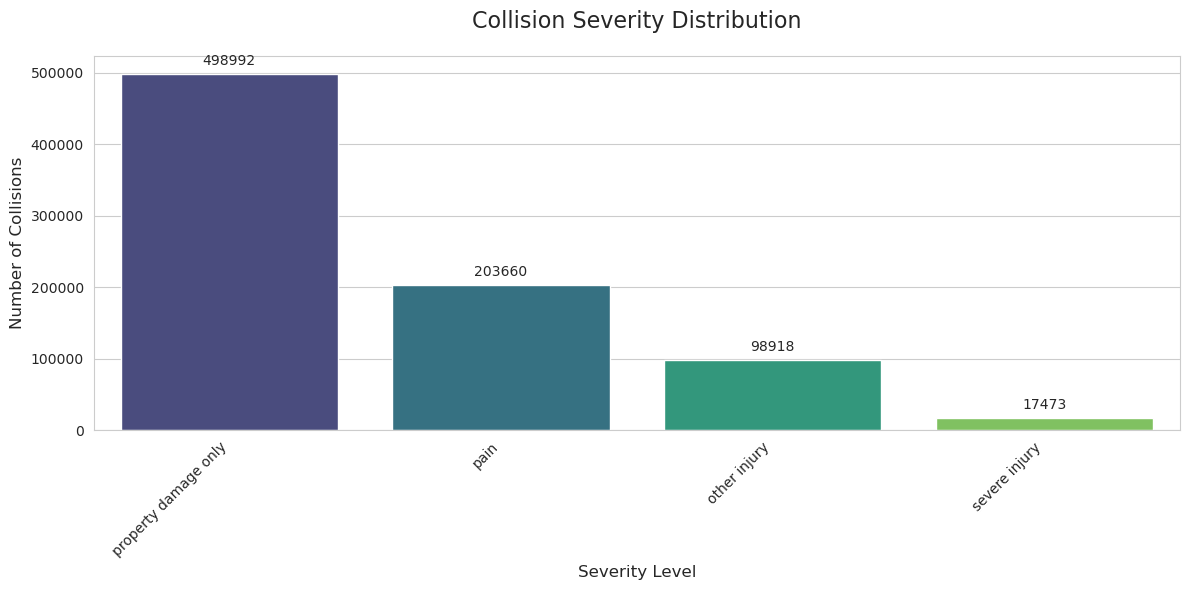

In [23]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

#Extracting labels from metadata
labels = collisions_final.schema["collision_severity_idx"].metadata["ml_attr"]["vals"]

# Convert to Pandas
severity_pdf = collisions_final.groupBy("collision_severity_idx").count().toPandas()

#mapping to index column
severity_pdf['severity_label'] = severity_pdf['collision_severity_idx'].apply(lambda x: labels[int(x)])


# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Sort the data by count so the most frequent categories are first
severity_pdf = severity_pdf.sort_values(by="count", ascending=False)

ax = sns.barplot(
    x="severity_label", 
    y="count", 
    data=severity_pdf, 
    palette="viridis"
)

# Formatting
plt.title("Collision Severity Distribution", fontsize=16, pad=20)
plt.xlabel("Severity Level", fontsize=12)
plt.ylabel("Number of Collisions", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add values on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig("collision_severity_univariate_labeled.png")
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red></font> <br>

Q: Examine weather conditions during collisions.

/tmp/ipykernel_31356/49825636.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

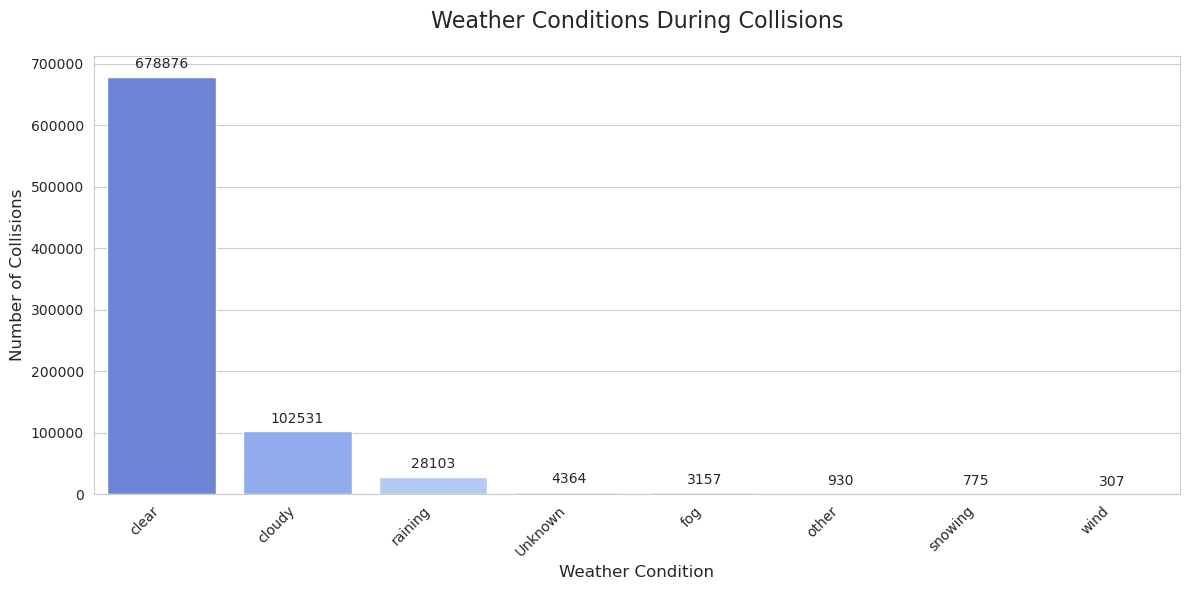

In [24]:
# Weather Conditions During Collisions

# 1. Extract the labels for Weather from the metadata
# 'weather_1_idx' was the column created during StringIndexing
weather_labels = collisions_final.schema["weather_1_idx"].metadata["ml_attr"]["vals"]

# Convert to Pandas

# 2. Aggregate counts in Spark and convert to Pandas
weather_pdf = collisions_final.groupBy("weather_1_idx").count().toPandas()

# 3. Map the numerical indices to the actual string labels
weather_pdf['weather_condition'] = weather_pdf['weather_1_idx'].apply(lambda x: weather_labels[int(x)])

# 4. Sort by count for better visualization
weather_pdf = weather_pdf.sort_values(by="count", ascending=False)


# Plot

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x="weather_condition", 
    y="count", 
    data=weather_pdf, 
    palette="coolwarm"
)

# Formatting the chart
plt.title("Weather Conditions During Collisions", fontsize=16, pad=20)
plt.xlabel("Weather Condition", fontsize=12)
plt.ylabel("Number of Collisions", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig("weather_conditions_univariate.png")
plt.show()


In [27]:
%whos

Variable                    Type            Data/Info
-----------------------------------------------------
F                           module          <module 'pyspark.sql.func<...>yspark/sql/functions.py'>
SparkSession                type            <class 'pyspark.sql.session.SparkSession'>
StringIndexer               ABCMeta         <class 'pyspark.ml.feature.StringIndexer'>
THRESHOLD                   float           50.0
a                           int             921460
after_counts                dict            n=4
ax                          Axes            Axes(0.0821065,0.167976;0.905394x0.730728)
b                           int             942433
before_counts               dict            n=4
case_ids                    DataFrame       DataFrame[case_id: double, db_year: int]
case_ids_clean              DataFrame       DataFrame[case_id: bigint, db_year: int]
case_ids_final              DataFrame       DataFrame[case_id: bigint, db_year: int]
check_missing               f

##**3.1.4. Victime Age Distribution.** <font color = red></font> <br>

Q: Analyze the distribution of victim ages.

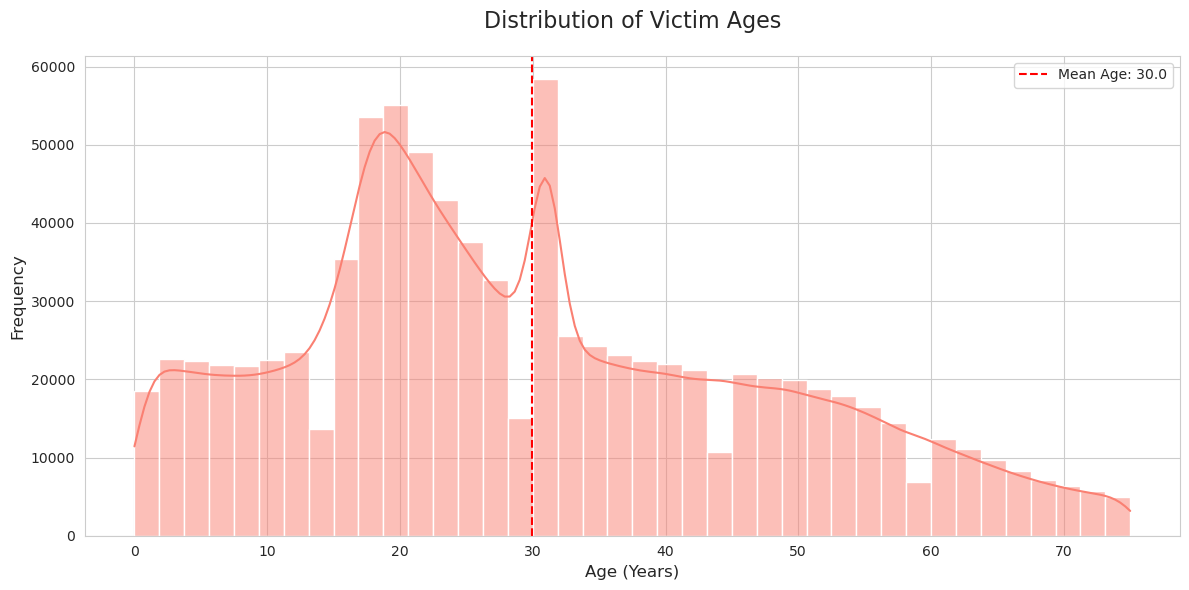

In [30]:
# Distribution of Victim Ages

# Convert to Pandas
age_pdf = victims_final.select("victim_age").toPandas()
# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

#Using histplot for numerical data to see the 'shape' of the population
sns.histplot(
    age_pdf["victim_age"], 
    bins=40,            # Groups ages into 40 'buckets'
    kde=True,           # Adds a kernel density estimate (the smooth line)
    color="salmon",
    edgecolor="white"
)

#Format
plt.title("Distribution of Victim Ages", fontsize=16, pad=20)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Adding a line for the average age
mean_age = age_pdf["victim_age"].mean()
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Age: {mean_age:.1f}')
plt.legend()

plt.tight_layout()
plt.savefig("victim_age_distribution_final.png")
plt.show()


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red></font> <br>

Q: Study the relationship between collision severity and the number of victims.

/tmp/ipykernel_31356/1309267275.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_31356/1309267275.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

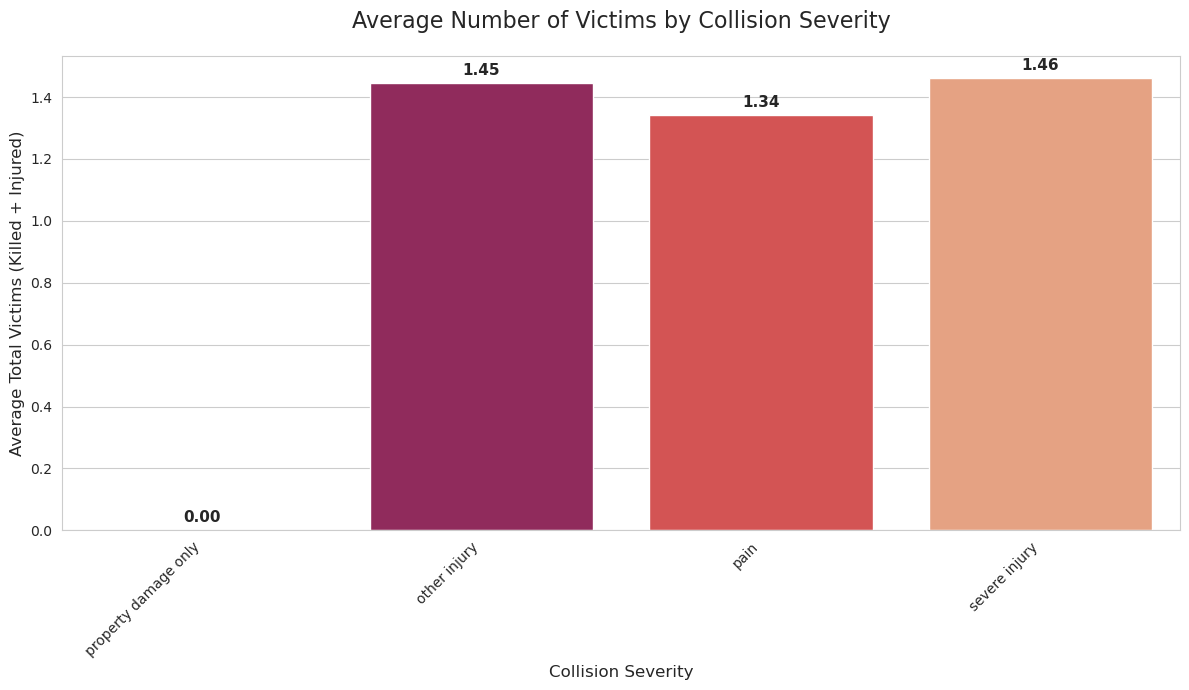

In [31]:
# Bivariate Analysis
bivariate_df = collisions_final.withColumn(
    "total_victims", 
    F.col("killed_victims") + F.col("injured_victims")
).select("collision_severity_idx", "total_victims")

#Extract Labels from Metadata
severity_labels = collisions_final.schema["collision_severity_idx"].metadata["ml_attr"]["vals"]

# Collision Severity vs. Number of Victims

# Convert to Pandas
bivariate_pdf = bivariate_df.toPandas()

#Map the labels
bivariate_pdf['severity_label'] = bivariate_pdf['collision_severity_idx'].apply(lambda x: severity_labels[int(x)])


# Plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# We use a Bar Plot to show the AVERAGE number of victims for each severity level
# This clearly shows the relationship: higher severity = more victims on average
ax = sns.barplot(
    x="severity_label", 
    y="total_victims", 
    data=bivariate_pdf, 
    palette="rocket",
    ci=None # Removes error bars for a cleaner look
)

#Format
plt.title("Average Number of Victims by Collision Severity", fontsize=16, pad=20)
plt.xlabel("Collision Severity", fontsize=12)
plt.ylabel("Average Total Victims (Killed + Injured)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add the mean value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("severity_vs_victims_bivariate.png")
plt.show()


##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red></font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

In [32]:
import gc

# 1. List all intermediate DataFrames that are no longer needed
# Keeping only 'collisions_final'
intermediates = [
    'collisions', 'collisions_clean', 'collisions_indexed',
    'parties', 'parties_clean', 'parties_indexed',
    'victims', 'victims_clean', 'victims_indexed',
    'case_ids', 'case_ids_clean'
]

for var in intermediates:
    if var in globals():
        del globals()[var]

# 2. Clear the Spark internal memory 
spark.catalog.clearCache()

# 3. Force Python to release the "pointers"
gc.collect()

4226

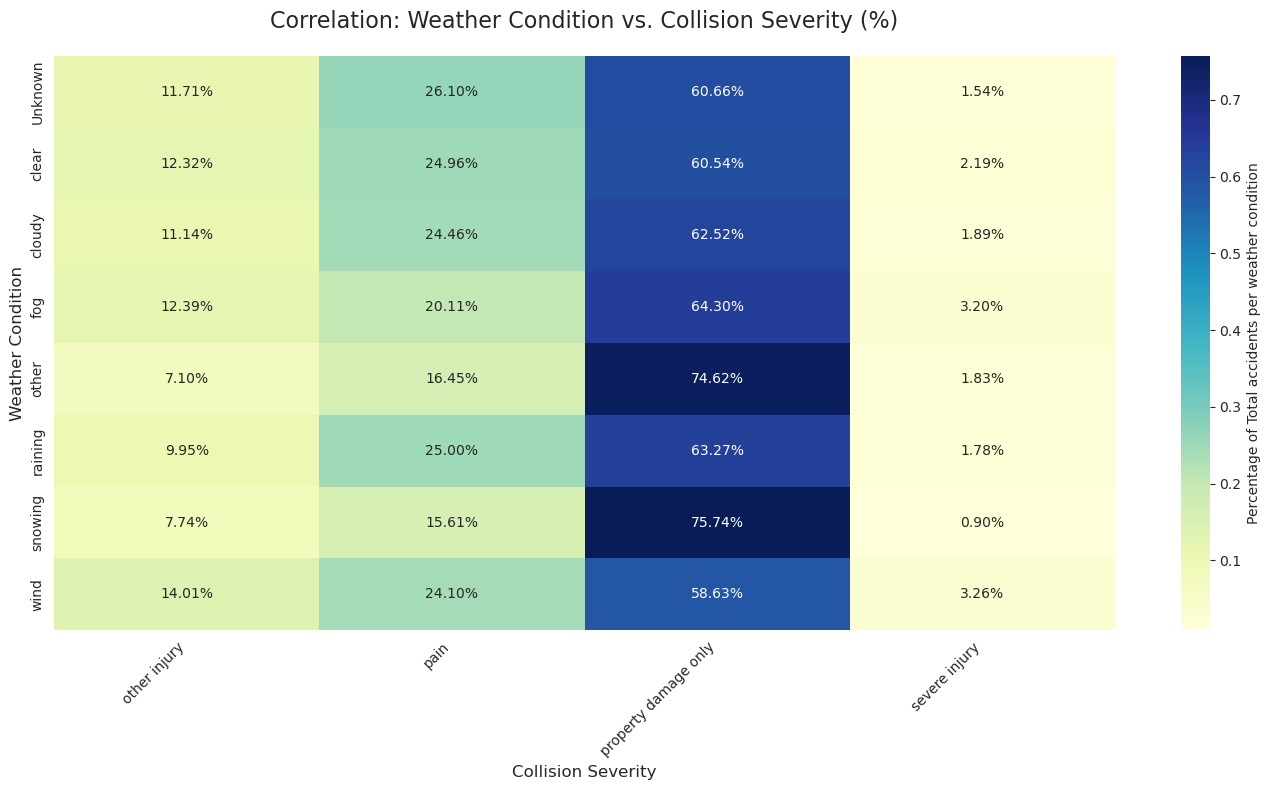

In [33]:
# Weather vs. Collision Severity
#Extract Labels for both columns from metadata
weather_labels = collisions_final.schema["weather_1_idx"].metadata["ml_attr"]["vals"]
severity_labels = collisions_final.schema["collision_severity_idx"].metadata["ml_attr"]["vals"]

# Convert to Pandas
#Aggregate in Spark and convert to Pandas
#We group by both indices to see the count of every combination
#fixing .toPandas() heavy operation which is leading to spark engine crashing
# 1. Small aggregation first
agg_df = collisions_final.groupBy("weather_1_idx", "collision_severity_idx").count()

# 2. Cache ONLY the tiny result to stabilize it
agg_df.cache()

# 3. Now move it to Pandas (this is much less likely to crash)
weather_severity_pdf = agg_df.toPandas()

# 4. Clean up the small cache immediately after
agg_df.unpersist()

#Map numerical indices back to text labels
weather_severity_pdf['weather'] = weather_severity_pdf['weather_1_idx'].apply(lambda x: weather_labels[int(x)])
weather_severity_pdf['severity'] = weather_severity_pdf['collision_severity_idx'].apply(lambda x: severity_labels[int(x)])

#Create a Pivot Table (Crosstab)
# This creates a matrix where rows are Weather and columns are Severity
pivot_table = weather_severity_pdf.pivot(index='weather', columns='severity', values='count').fillna(0)

#Normalization
# Since 'Clear' weather has way more accidents than 'Rain', we normalize by row 
# to see the % distribution of severity WITHIN each weather type.
pivot_norm = pivot_table.div(pivot_table.sum(axis=1), axis=0)


# Plot
#Plotting the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_norm, annot=True, fmt=".2%", cmap="YlGnBu", cbar_kws={'label': 'Percentage of Total accidents per weather condition'})

# Formatting
plt.title("Correlation: Weather Condition vs. Collision Severity (%)", fontsize=16, pad=20)
plt.xlabel("Collision Severity", fontsize=12)
plt.ylabel("Weather Condition", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("weather_vs_severity_heatmap.png")
plt.show()



##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red></font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

In [34]:
#Breathing room for spark first
#Reduce shuffle partitions to prevent overhead on small aggregations
spark.conf.set("spark.sql.shuffle.partitions", "50")

# Break any lingering lineage and clear RAM
gc.collect()

6765

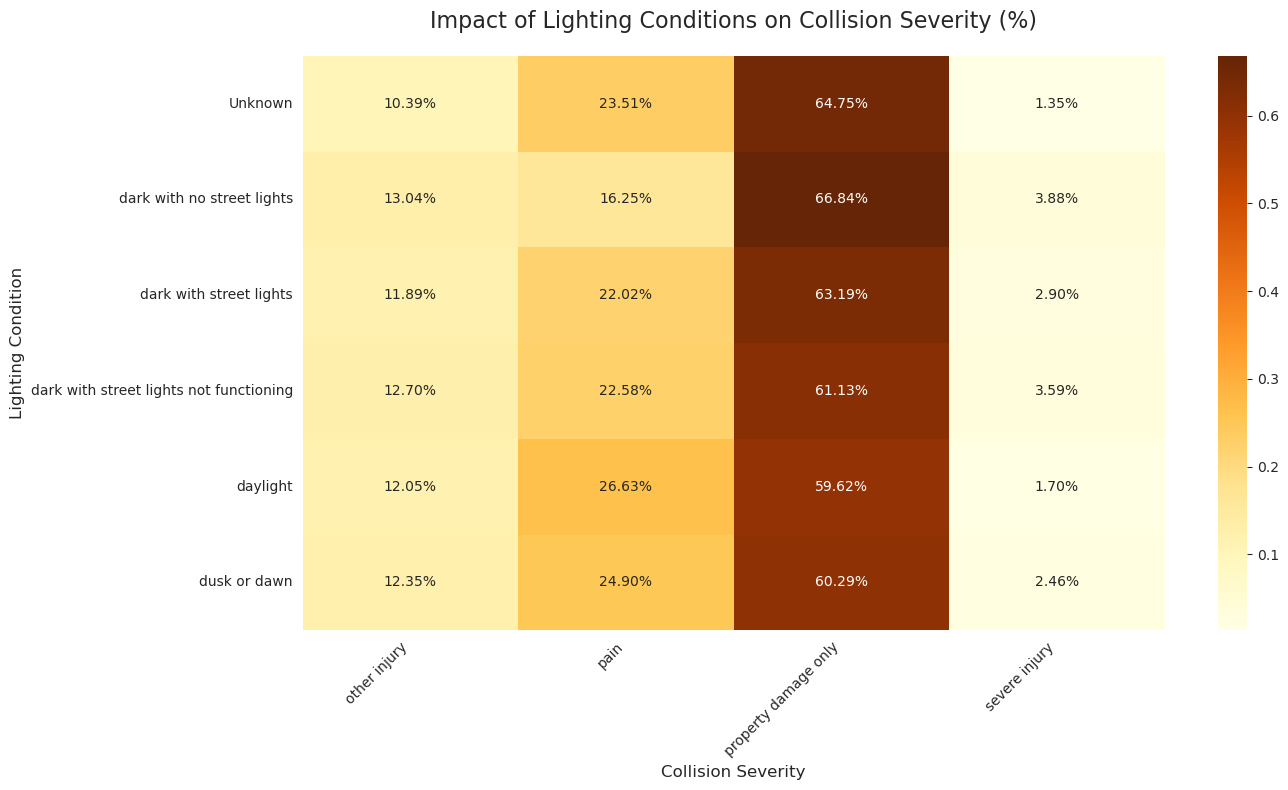

In [35]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas
# 1. Extract Labels from metadata
lighting_labels = collisions_final.schema["lighting_idx"].metadata["ml_attr"]["vals"]
severity_labels = collisions_final.schema["collision_severity_idx"].metadata["ml_attr"]["vals"]

# 2. Aggregate in Spark (The "Heavy" work happens in the cluster)
lighting_severity_agg = collisions_final.groupBy("lighting_idx", "collision_severity_idx").count()

# 3. Convert the small aggregated result to Pandas
lighting_pdf = lighting_severity_agg.toPandas()

# 4. Map indices back to text labels for readability
lighting_pdf['lighting'] = lighting_pdf['lighting_idx'].apply(lambda x: lighting_labels[int(x)])
lighting_pdf['severity'] = lighting_pdf['collision_severity_idx'].apply(lambda x: severity_labels[int(x)])

# 5. Pivot for visualization
pivot_lighting = lighting_pdf.pivot(index='lighting', columns='severity', values='count').fillna(0)

# 6. Normalize by row (Percentage of severity per lighting condition)
pivot_lighting_norm = pivot_lighting.div(pivot_lighting.sum(axis=1), axis=0)
# Plot

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_lighting_norm, annot=True, fmt=".2%", cmap="YlOrBr")

# Formatting
plt.title("Impact of Lighting Conditions on Collision Severity (%)", fontsize=16, pad=20)
plt.xlabel("Collision Severity", fontsize=12)
plt.ylabel("Lighting Condition", fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red></font> <br>

Q: Extract and analyze weekday-wise collision trends.

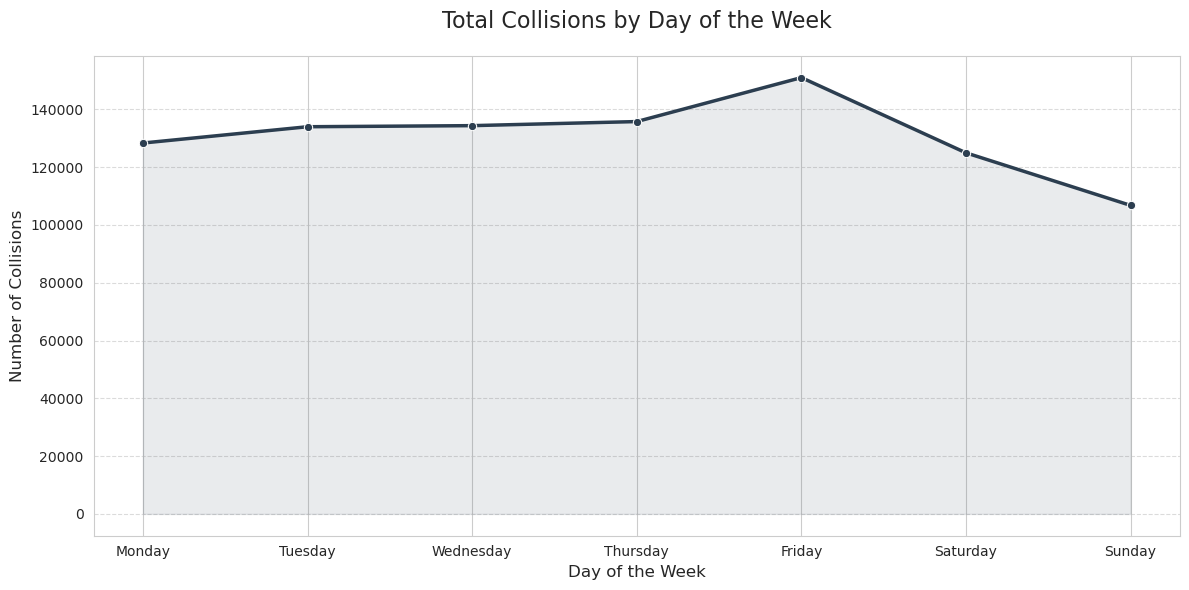

In [46]:
gc.collect()
# Extract the weekday
# 1. Extract weekday and aggregate
weekday_counts_df = collisions_clean.withColumn("weekday", F.date_format("collision_date", "EEEE")) \
    .groupBy("weekday") \
    .count()

# 2. Convert the small summary (only 7 rows!) to Pandas
weekday_pdf = weekday_counts_df.toPandas()

# 3. Sort chronologically (Pandas won't know the order of days automatically)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_pdf['weekday'] = pd.Categorical(weekday_pdf['weekday'], categories=days_order, ordered=True)
weekday_pdf = weekday_pdf.sort_values("weekday")
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=weekday_pdf, x='weekday', y='count', marker='o', linewidth=2.5, color='#2c3e50')
plt.fill_between(weekday_pdf['weekday'], weekday_pdf['count'], alpha=0.1, color='#2c3e50')

# Formatting
plt.title("Total Collisions by Day of the Week", fontsize=16, pad=20)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Collisions", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


##**3.1.9. Spatial Distribution of Collisions.** <font color = red></font> <br>

Q: Study spatial distribution of collisions by county.

/tmp/ipykernel_31356/3087580615.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=county_pdf.head(30), x='count', y='county_location', palette="flare")
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: 

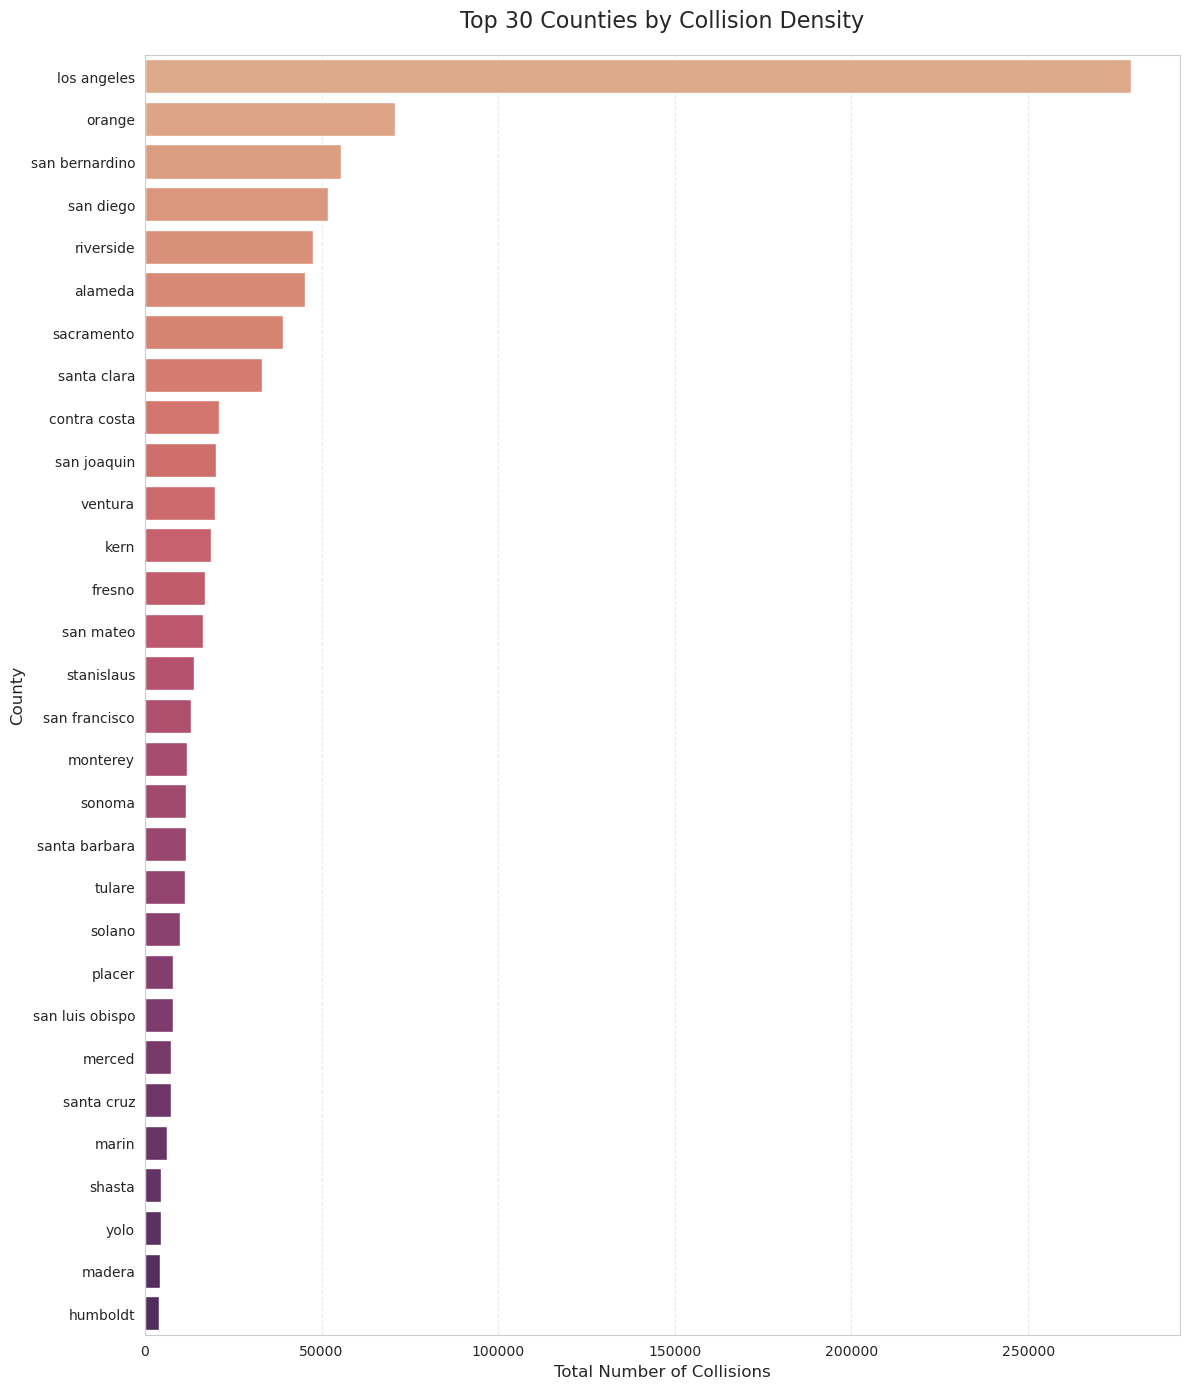

In [47]:
# Spatial Analysis
gc.collect()
# Collision Density by County
# 1. Aggregate collision counts by county
#using collisions_clean because it contains the actual County names
county_density_df = collisions_clean.groupBy("county_location").count()

# 2. Sort by count descending in Spark before bringing to Pandas
county_density_df = county_density_df.orderBy(F.col("count").desc())

# 3. Bring the summarized data to Pandas
# (Typically ~58 counties in CA, so this is very safe for the engine)
county_pdf = county_density_df.toPandas()

# 4. Cleanup
del county_density_df
gc.collect()
# Plot the map

plt.figure(figsize=(12, 14)) # Taller figure to fit county names
sns.barplot(data=county_pdf.head(30), x='count', y='county_location', palette="flare")

# Formatting
plt.title("Top 30 Counties by Collision Density", fontsize=16, pad=20)
plt.xlabel("Total Number of Collisions", fontsize=12)
plt.ylabel("County", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


##**3.1.10. Collision Analysis by Geography.** <font color = red></font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

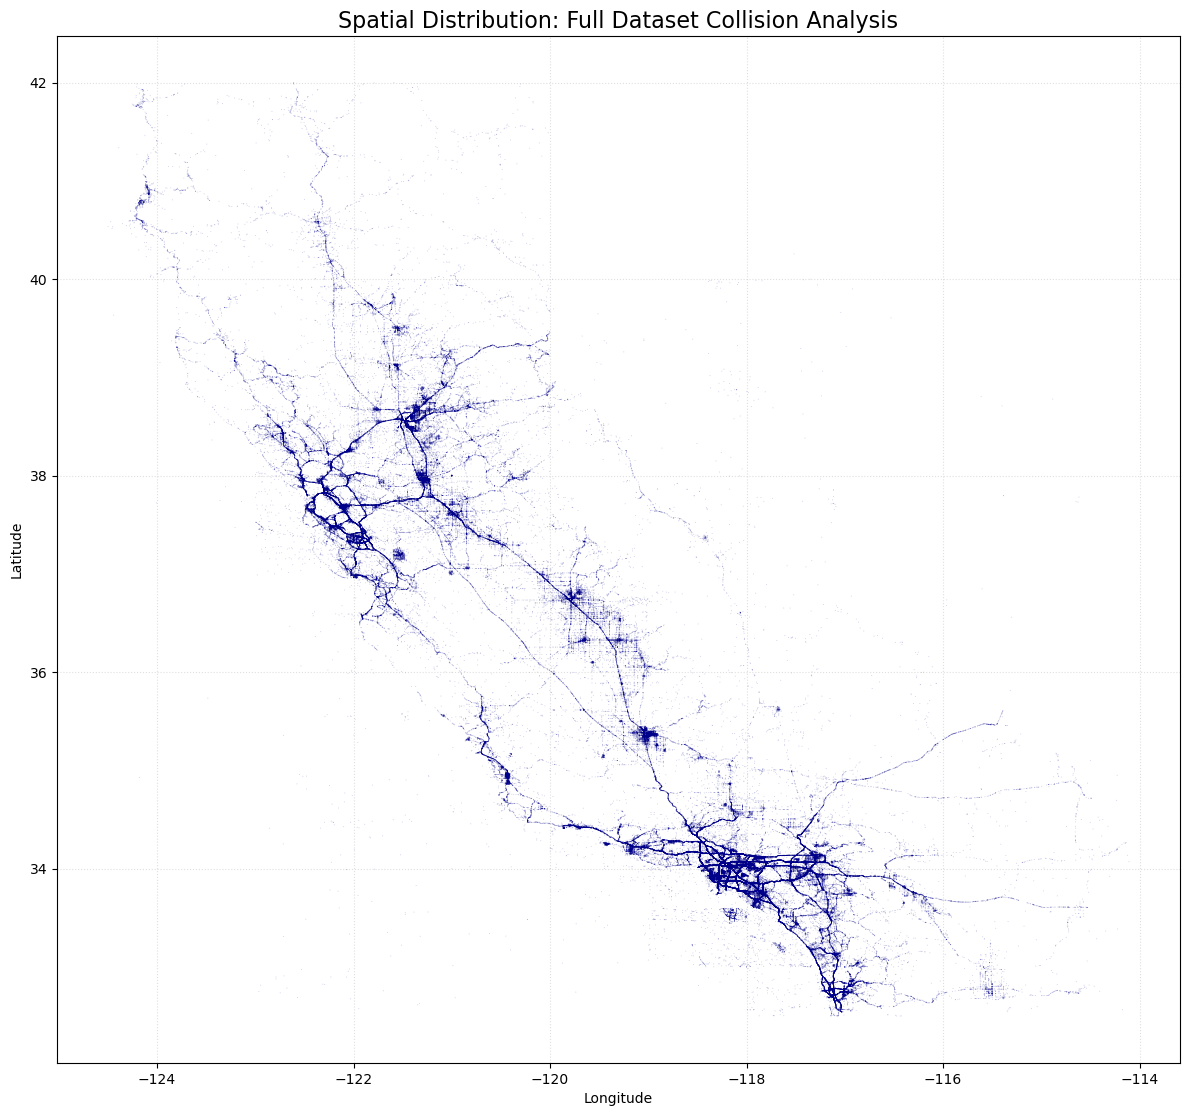

In [8]:
import matplotlib.pyplot as plt
import gc
# Scatter Plot of Collision Locations
lat_long_data = spark.read.parquet(
    "s3a://mybucket/lat_long_data.parquet",
    header=True,
    inferSchema=True
)

# Since we already filtered for nulls before saving to minio bucket, we just pull it all


# Convert PySpark DataFrame to Pandas, handling potential missing values
geo_pdf = lat_long_data.select("latitude", "longitude").toPandas()
# Convert to numeric (if needed) and handle invalid data
# Ensuring they are floats and drop any remaining zeros or invalid entries
geo_pdf['latitude'] = pd.to_numeric(geo_pdf['latitude'], errors='coerce')
geo_pdf['longitude'] = pd.to_numeric(geo_pdf['longitude'], errors='coerce')

#filtering  for California bounds
# Filter for CA bounds to keep the map scale correct
geo_pdf = geo_pdf[
    (geo_pdf['latitude'] > 32.5) & (geo_pdf['latitude'] < 42.0) &
    (geo_pdf['longitude'] > -124.5) & (geo_pdf['longitude'] < -114.0)
]


# Plot the scatter plot

plt.figure(figsize=(12, 14))

# s=0.5: Very small points to avoid a massive overlap "blob"
# rasterized=True: Tells Matplotlib to treat the points as a bitmap (saves RAM)
plt.scatter(
    geo_pdf['longitude'], 
    geo_pdf['latitude'], 
    s=0.5, 
    alpha=0.2, 
    color='darkblue', 
    edgecolors='none',
    rasterized=True 
)

# Aesthetics
plt.title("Spatial Distribution: Full Dataset Collision Analysis", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.4)

# Memory management before final display
del lat_long_data
gc.collect()

plt.tight_layout()
plt.show()


##**3.1.11. Collision Trends Over Time.** <font color = red></font> <br>

Extract and analyzing collision trends over time.

In [29]:
from pyspark.sql import functions as F
import gc

temporal_base = collisions_clean.select("collision_date", "collision_time")

# 2. Extract features
# We use 'collision_date' for Year/Month and 'collision_time' for Hour
temporal_features = temporal_base.withColumn("year", F.year("collision_date")) \
    .withColumn("month_num", F.month("collision_date")) \
    .withColumn("month_name", F.date_format("collision_date", "MMMM")) \
    .withColumn("hour", F.hour("collision_time")) # Directly extract from Timestamp

# 3. Create the small Pandas DataFrames
yearly_pdf = temporal_features.groupBy("year").count().orderBy("year").toPandas()
monthly_pdf = temporal_features.groupBy("month_num", "month_name").count().orderBy("month_num").toPandas()
hourly_pdf = temporal_features.groupBy("hour").count().orderBy("hour").toPandas()

# 4. Cleanup
del temporal_base, temporal_features
gc.collect()


9813

Q: Analyze yearly, monthly and hourly trends in collisions.

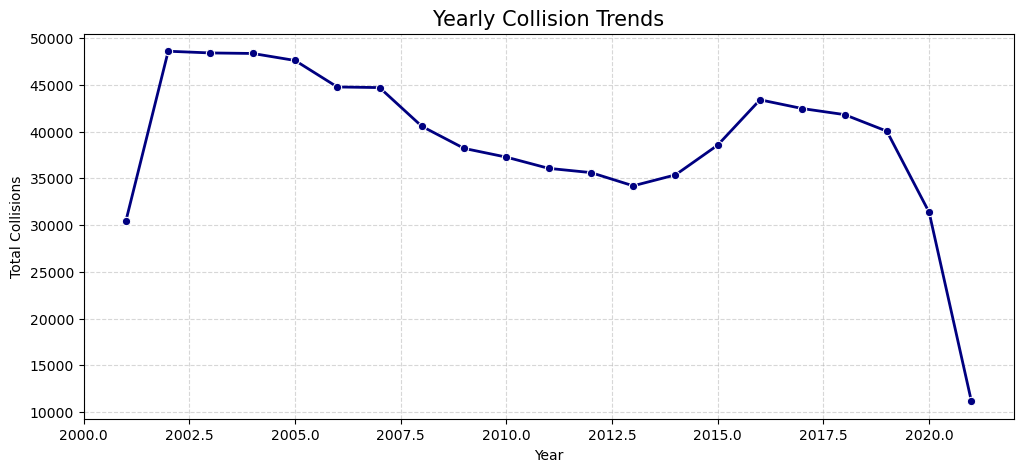

In [31]:
# Yearly Trend of Collisions
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_pdf, x='year', y='count', marker='o', color='navy', linewidth=2)

plt.title("Yearly Collision Trends", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Total Collisions")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When 

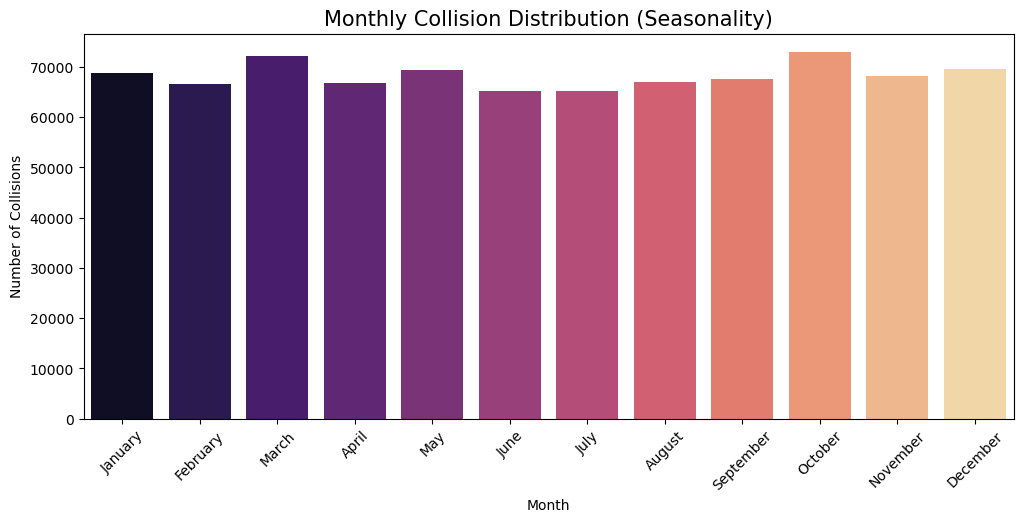

In [25]:
# Monthly Trend of Collisions

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_pdf, x='month_name', y='count', palette="magma", hue='month_name', legend=False)

plt.title("Monthly Collision Distribution (Seasonality)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.show()


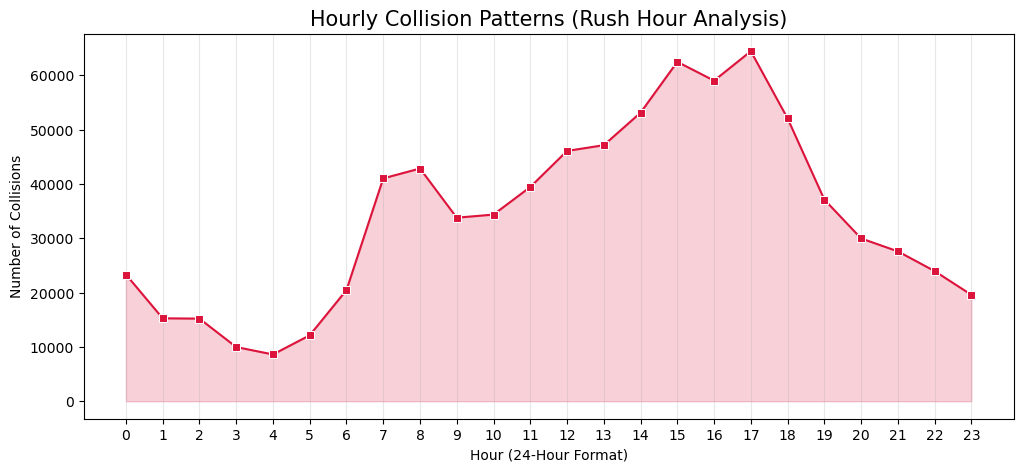

In [32]:
# Hourly Trend of Collisions

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pdf, x='hour', y='count', marker='s', color='crimson')
plt.fill_between(hourly_pdf['hour'], hourly_pdf['count'], alpha=0.2, color='crimson')

plt.title("Hourly Collision Patterns (Rush Hour Analysis)", fontsize=15)
plt.xlabel("Hour (24-Hour Format)")
plt.ylabel("Number of Collisions")
plt.xticks(range(0, 24))
plt.grid(True, axis='x', alpha=0.3)
plt.show()

#**4. ETL Querying** <font color = red></font> <br>

##**4.1 Loading the Dataset** <font color = red></font> <br>

Q: Load the processed dataset as CSV files in S3 bucket.

In [ ]:
# Write your query here
output_path = "s3a://mybucket/"
file_path = f"{output_path}collisions_final.parquet"

collisions_final = spark.read.parquet(file_path)

## **4.2. Top 5 Counties** <font color = red></font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [12]:
# Query: Identify the top 5 counties with the most collisions
# Aggregate by county index
top_counties = collisions_final.groupBy("county_location_idx").count().orderBy("count", ascending=False).limit(5)

# Map labels from metadata
county_labels = collisions_final.schema["county_location_idx"].metadata["ml_attr"]["vals"]
top_counties_pdf = top_counties.toPandas()
top_counties_pdf['county'] = top_counties_pdf['county_location_idx'].apply(lambda x: county_labels[int(x)])

print(top_counties_pdf[['county', 'count']])


           county   count
0     los angeles  265550
1          orange   65950
2  san bernardino   47160
3       san diego   44559
4         alameda   40645


##**4.3. Month with Highest Collisions** <font color = red></font> <br>

Q. Identify the month with the highest number of collisions.

In [13]:
# Query: Find the month with the highest number of collisions
from pyspark.sql import functions as F

month_agg = collisions_clean.withColumn("month", F.date_format("collision_date", "MMMM")) \
    .groupBy("month").count().orderBy("count", ascending=False).limit(1)

month_agg.show()

+-------+-----+
|  month|count|
+-------+-----+
|October|72975|
+-------+-----+



##**4.4. Weather Conditions with Highest Collisions.** <font color = red></font> <br>

Q. Determine the most common weather condition during collisions.

In [14]:
# Query: Find the most common weather condition during collisions
weather_agg = collisions_final.groupBy("weather_1_idx").count().orderBy("count", ascending=False).limit(1)

# Map label
weather_labels = collisions_final.schema["weather_1_idx"].metadata["ml_attr"]["vals"]
top_weather = weather_agg.toPandas()
print(f"Most common weather: {weather_labels[int(top_weather['weather_1_idx'][0])]}")

Most common weather: clear


##**4.5. Fatal Collisions.** <font color = red></font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [19]:
# Check the maximum value in the column
collisions_clean.select(F.max("killed_victims"), F.sum("killed_victims")).show()

# Check the distribution of Severity
# Usually, Severity '1' = Fatal
collisions_clean.groupBy("collision_severity").count().orderBy("collision_severity").show()

+-------------------+-------------------+
|max(killed_victims)|sum(killed_victims)|
+-------------------+-------------------+
|                  0|                  0|
+-------------------+-------------------+

+--------------------+------+
|  collision_severity| count|
+--------------------+------+
|        other injury| 98918|
|                pain|203660|
|property damage only|498992|
|       severe injury| 17473|
+--------------------+------+



In [24]:
# Query: Determine the percentage of collisions that resulted in fatalities
# 1. Total unique collisions (from your clean collisions table)
total_collisions = collisions_clean.count()

# 2. Find unique case_ids in the parties table that had at least one death
# This ensures a single accident with 2 deaths isn't counted as 2 accidents
fatal_case_ids = parties_clean.filter(F.col("party_number_killed") > 0) \
    .select("case_id") \
    .distinct()

fatal_collisions_count = fatal_case_ids.count()

# 3. Calculate percentage with float precision
if total_collisions > 0:
    percentage_fatal = (fatal_collisions_count / total_collisions) * 100
    print(f"Total Collisions: {total_collisions:,}")
    print(f"Collisions with at least one fatality: {fatal_collisions_count:,}")
    print(f"Percentage of fatal collisions: {percentage_fatal:.2f}%")
else:
    print("No collision data found.")

Total Collisions: 819,043
Collisions with at least one fatality: 5,767
Percentage of fatal collisions: 0.70%


##**4.6. Dangerous Time for Collisions.** <font color = red></font> <br>

Q. Find the most dangerous time of day for collisions.

In [16]:
# Query: Find the most dangerous time of day for collisions

# 1. Group by the hour extracted directly from the Timestamp column
dangerous_time_df = collisions_clean.groupBy(F.hour("collision_time").alias("hour")) \
    .count() \
    .orderBy("count", ascending=False)

# 2. Extract the top result
top_hour_row = dangerous_time_df.first()
top_hour = top_hour_row['hour']
collision_count = top_hour_row['count']

print(f"The most dangerous time of day is the {top_hour}:00 hour with {collision_count:,} collisions.")


The most dangerous time of day is the 17:00 hour with 64,438 collisions.


##**4.7. Road Surface Conditions.** <font color = red></font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [17]:
# Query: List the top 5 road types with the highest collision frequency
road_surface_agg = collisions_final.groupBy("road_surface_idx").count().orderBy("count", ascending=False).limit(5)

# Map labels
surface_labels = collisions_final.schema["road_surface_idx"].metadata["ml_attr"]["vals"]
top_surfaces = road_surface_agg.toPandas()
top_surfaces['condition'] = top_surfaces['road_surface_idx'].apply(lambda x: surface_labels[int(x)])

print(top_surfaces[['condition', 'count']])

  condition   count
0       dry  743485
1       wet   64694
2   Unknown    7651
3     snowy    2396
4  slippery     807


##**4.8. Lighting Conditions.** <font color = red></font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [18]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
lighting_agg = collisions_final.groupBy("lighting_idx").count().orderBy("count", ascending=False).limit(3)

# Map labels
lighting_labels = collisions_final.schema["lighting_idx"].metadata["ml_attr"]["vals"]
top_lighting = lighting_agg.toPandas()
top_lighting['condition'] = top_lighting['lighting_idx'].apply(lambda x: lighting_labels[int(x)])

print(top_lighting[['condition', 'count']])

                    condition   count
0                    daylight  549083
1     dark with street lights  185031
2  dark with no street lights   50130


#5. Conclusion <font color = red></font> <br>

Write your conclusion.

# Final insights and recommendations
# 6. Conclusion

This analysis demonstrates that traffic collisions in California are driven less by rare extreme conditions and more by everyday traffic volume, commuting behavior, infrastructure gaps, and predictable human risk patterns. Most crashes occurred in clear weather, dry roads, and daylight conditions, which indicates that accidents are primarily an **exposure problem**—not a weather problem. People crash most when roads are busiest, not necessarily when conditions are worst.

Evening rush hour (**5 PM**) represents the single highest-risk time, while Fridays recorded the most collisions. This indicates that congestion, fatigue, impatience, and end-of-week traffic pressure are stronger collision drivers than random environmental factors. Traffic enforcement and signal optimization should therefore focus on weekday peak windows rather than distributing resources evenly across the day.

**Los Angeles County** overwhelmingly leads collision volume, followed by other dense urban counties. This means collision prevention should be geographically prioritized; a statewide uniform strategy would waste resources while high-density counties need targeted interventions such as smarter intersections and faster incident response.

Nighttime collisions were fewer in number but more severe, especially in areas without street lighting. This is one of the clearest actionable findings: better lighting infrastructure can reduce severe outcomes faster than many awareness campaigns, offering a measurable ROI.

Young adults (roughly late teens to mid-20s) appeared most frequently among victims, suggesting inexperience and higher exposure. Driver education and targeted safety programs should prioritize this demographic.

From a data perspective, the ETL process successfully transformed messy raw relational records into analysis-ready datasets. Duplicate removal, null handling, type correction, and outlier treatment significantly improved reliability for future ML models and forecasting systems.

---

### Final Business Reality

If an agency had to act tomorrow, the smartest moves would be:

* **Targeted Enforcement:** Focus control during 4 PM–7 PM on weekdays.
* **Infrastructure:** Upgrade lighting in dark high-collision corridors.
* **Geography:** Prioritize Los Angeles and Southern California hubs first.
* **Demographics:** Build specific interventions for young drivers.
* **Analytics:** Use predictive models to forecast hotspot times and locations.

> **Bottom Line:** The problem is not unpredictable crashes. The problem is repeated collisions in known places, known times, and known conditions. It is manageable with targeted, data-led intervention.

---

## 6.1 Road Safety Recommendations

* **Target Young Drivers:** Implement targeted safety awareness campaigns for the 18–25 age group.
* **Enhance Nighttime Infrastructure:** Accelerate the installation and maintenance of street lighting in high-speed areas; dark roads correlate with the highest severe injury rates.
* **Safety Feature Promotion:** Continue promoting advanced safety features like airbags and crumple zones to maintain the high volume of non-injury outcomes.

## 6.2 Traffic Management Suggestions

* **Rush Hour Mitigation:** Increase traffic monitoring and deployments during the 5 PM evening peak.
* **Friday-Specific Protocols:** Develop management plans for Fridays to address the weekend transition spike.
* **Seasonal Readiness:** Prepare increased maintenance for **October**, the highest collision month due to earlier sunsets and initial rains.

## 6.3 Policy Improvements for Pedestrians & Cyclists

* **Visibility Standards:** Implement stricter lighting and reflective gear policies for nighttime travel.
* **Urban Speed Management:** Support policies that lower speed limits in high-density corridors to convert severe injuries into minor injuries or property damage outcomes.
* **Congestion-Focused Planning:** Prioritize pedestrian and cyclist separation in Southern California hubs.

## 6.4 High-Risk Zone Identification

* **Southern California Focus:** Los Angeles County is the highest-risk zone with the largest collision volume.
* **The Grapevine Bottleneck:** Tejon Pass is a critical area where elevation and steep grades intensify collision density.
* **Central Valley Arteries:** SR-99 shows higher collision density than I-5, requiring better intersection management.

## 6.5 Environmental Factor Impact

* **Clear Weather Paradox:** Most accidents occur in clear weather; focus efforts on human factors like distraction.
* **Wind and Fog Hazards:** High winds and fog show elevated severe injury risks.
* **The Slick Road Effect:** October’s peak is linked to oil buildup being released by first rains.

## 6.6 Predictive Analysis Opportunities

* **Incomplete Data Modelling:** Account for reporting delays and partial-year records in future forecasting.
* **Demographic Weighting:** Use age-based risk patterns to improve prediction models.
* **Time-Series Forecasting:** Use weekly and hourly traffic trends to predict collision volumes.

## 6.7 Key Findings & Business Implications

* **Economic Correlation:** Collision trends suggest traffic risk often moves with economic activity and commuting volume.
* **Infrastructure ROI:** Functioning street lights offer measurable safety benefits.
* **Public Safety Outcome:** Fatal collisions make up a small percentage of all reported accidents but carry the highest social cost.